In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dataset.csv', sep=';')

#colunas
#print(df.columns)
#print('='*10)

# AJUSTE DO SEPARADOR sep=';'
# LIMPAR OS NOMES DAS COLUNAS
df.columns = df.columns.str.strip()


print(df.info())

#tratamento 1 remover 'R$' e cast para numerico (str.replace() e pd.to_numeric())

print('='*10)

#replace
df['VALOR BRUTO DA FATURA'] = df['VALOR BRUTO DA FATURA'].replace('[R$]', '', regex=True)

print(df)
print('-'*5, 'REMOVENDO .')

df['VALOR BRUTO DA FATURA'] = df['VALOR BRUTO DA FATURA'].str.replace('.', '', regex=False)
print(df)

print('-'*5, 'ALTERANDO , POR .')
df['VALOR BRUTO DA FATURA'] = df['VALOR BRUTO DA FATURA'].str.replace(',','.')
print(df)

print('FAZENDO O CAST')
df['VALOR BRUTO DA FATURA'] = pd.to_numeric(df['VALOR BRUTO DA FATURA'], errors='coerce')

print('='*10)
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   ANO                    88 non-null     int64
 1   MÊS                    88 non-null     str  
 2   CONSUMO-KWH            88 non-null     int64
 3   VALOR BRUTO DA FATURA  88 non-null     str  
dtypes: int64(2), str(2)
memory usage: 2.9 KB
None
     ANO       MÊS  CONSUMO-KWH VALOR BRUTO DA FATURA
0   2017     Junho        27530             17.910,77
1   2017     Julho        30343             17.686,84
2   2017    Agosto        30997             19.449,47
3   2017  Setembro        36316             21.949,20
4   2017   Outubro        33980             21.031,11
..   ...       ...          ...                   ...
83  2024      Maio        18097             17.970,58
84  2024     Junho        19849             18.844,90
85  2024     Julho        17316             16.575,76
86  2024    Agosto

In [2]:
df.groupby('ANO')['CONSUMO-KWH'].sum()

ANO
2017    229830
2018    406657
2019    340356
2020    323081
2021    288993
2022    329116
2023    266935
2024    184256
Name: CONSUMO-KWH, dtype: int64

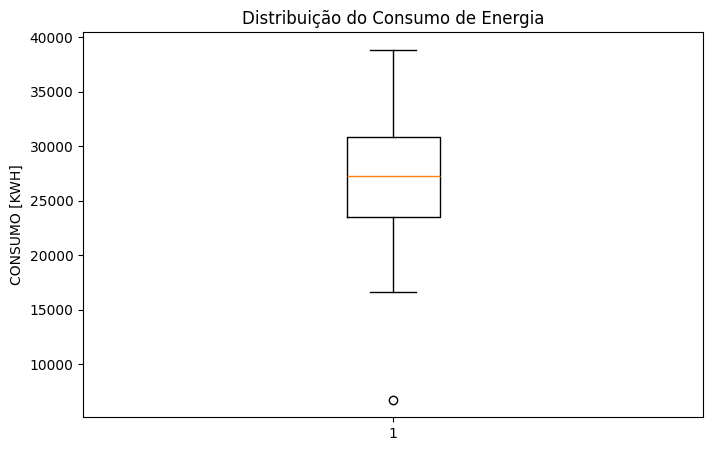

In [3]:
# PRIMEIRO GRÁFICO - BOXPLOT - para evidenciar mediana, quartis, dispersão...

plt.figure(figsize=(8,5))
plt.boxplot(df['CONSUMO-KWH'])
plt.title('Distribuição do Consumo de Energia')
plt.ylabel('CONSUMO [KWH]')
plt.show()

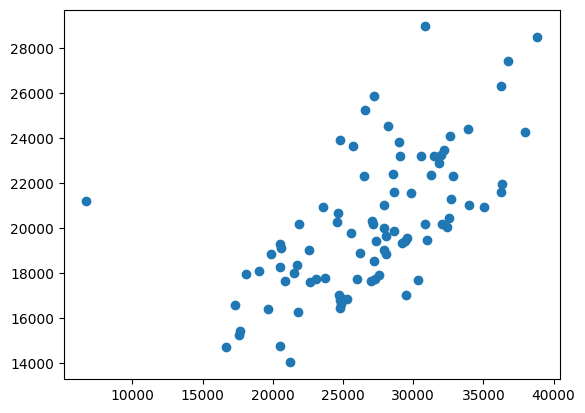

In [4]:
# SEGUNDO GRÁFICO - VERIFICAR DISPERSÃO DE DADOS - SCATTERPLOT

plt.scatter(df['CONSUMO-KWH'], df['VALOR BRUTO DA FATURA'])

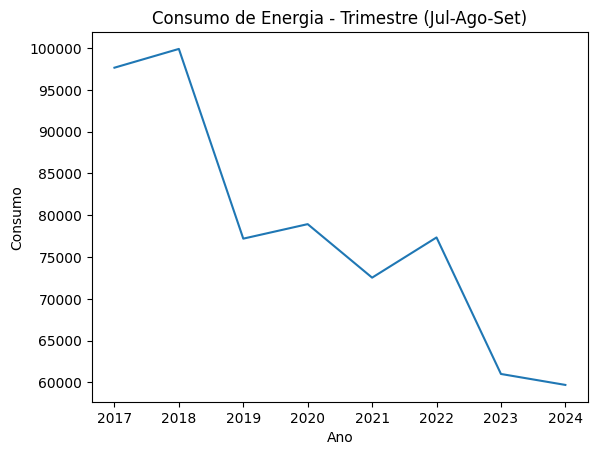

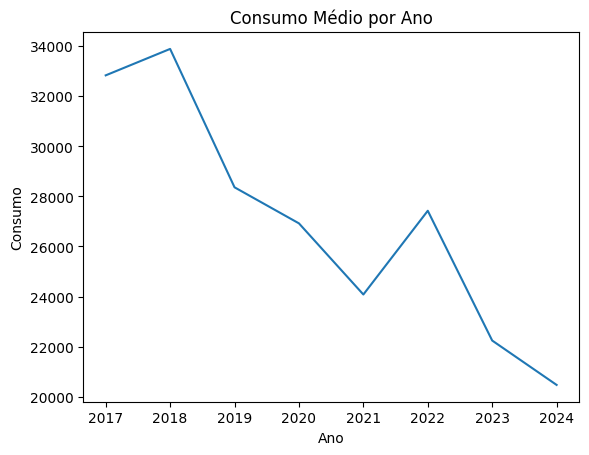

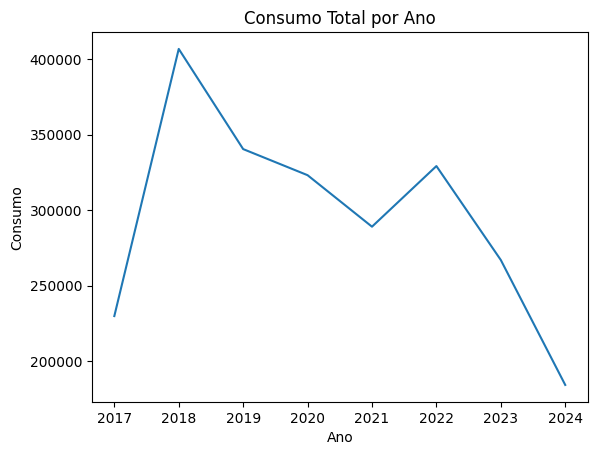

In [27]:
# Fazendo a separação dos dados do dataset; Criando o df_trimestre que contempla o trimestre de todos os anos do dataset em comum, para uma análise mais apurada.
# Criando o gráfico de linhas do trimestre.

df_trimestre = df[df['MÊS'].isin(['Julho', 'Agosto', 'Setembro'])]

#print(df_trimestre)

consumo_trimestre = df_trimestre.groupby('ANO')['CONSUMO-KWH'].sum()


plt.title('Consumo de Energia - Trimestre (Jul-Ago-Set)')
plt.xlabel('Ano')
plt.ylabel('Consumo')

plt.plot(consumo_trimestre.index, consumo_trimestre.values)
# Mais Explícito, seguro, melhor para produção e dashboards. Evitar problemas de 'dedução' do matplot
#plt.plot(consumo_trimestre)

plt.show()

###############################################################################################################################

# GRÁFICO DA MÉDIA DE CONSUMO ANUAL / GRÁFICO DE CONSUMO TOTAL POR ANO
a1 = df.groupby('ANO')['CONSUMO-KWH'].mean()

plt.title('Consumo Médio por Ano')
plt.xlabel('Ano')
plt.ylabel('Consumo')

plt.plot(a1.index, a1.values)
plt.show()

########################################
a2 = df.groupby('ANO')['CONSUMO-KWH'].sum()

plt.title('Consumo Total por Ano')
plt.xlabel('Ano')
plt.ylabel('Consumo')

plt.plot(a2.index, a2.values)
plt.show()

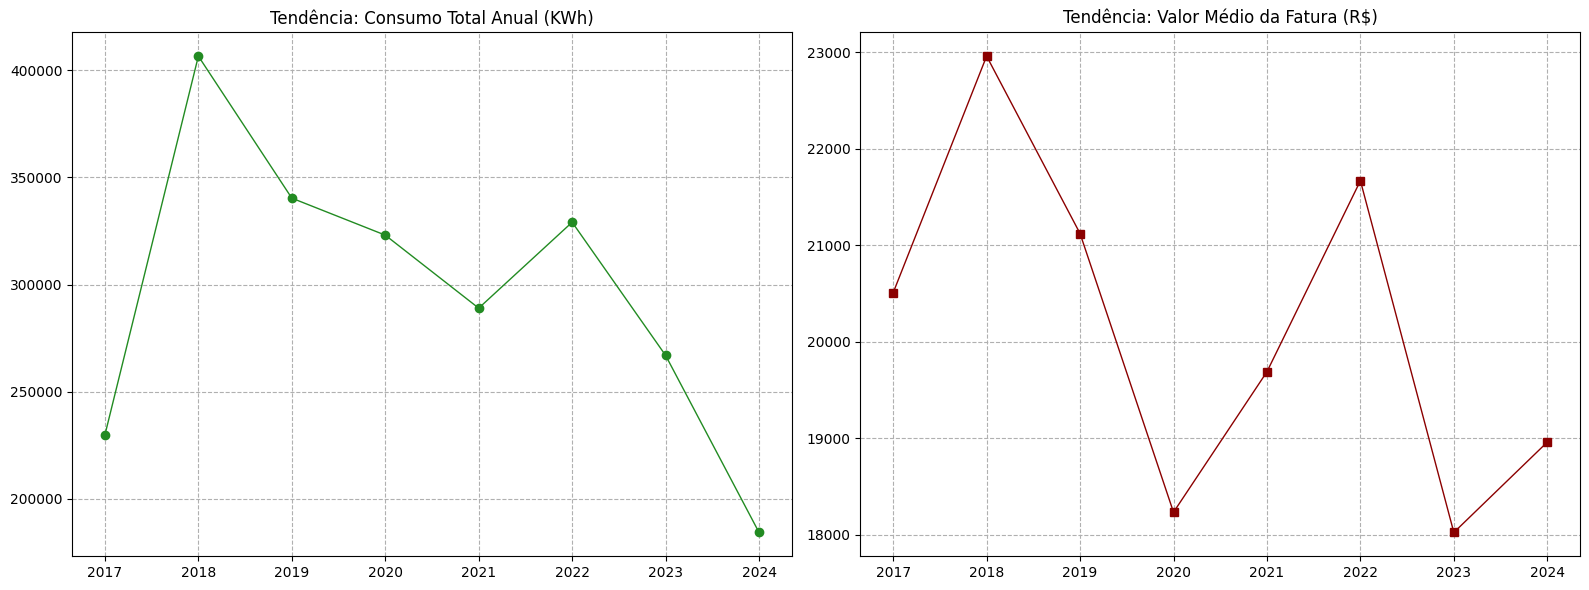

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

resumo_anual = df.groupby('ANO').agg({'CONSUMO-KWH': 'sum', 'VALOR BRUTO DA FATURA': 'mean'})

ax[0].plot(resumo_anual.index, resumo_anual['CONSUMO-KWH'], marker='o', color='forestgreen', linewidth=1)
ax[0].set_title('Tendência: Consumo Total Anual (KWh)')
ax[0].grid(True, linestyle='--')

ax[1].plot(resumo_anual.index, resumo_anual['VALOR BRUTO DA FATURA'], marker='s', color='darkred', linewidth=1)
ax[1].set_title('Tendência: Valor Médio da Fatura (R$)')
ax[1].grid(True, linestyle='--')

plt.tight_layout()
plt.show()


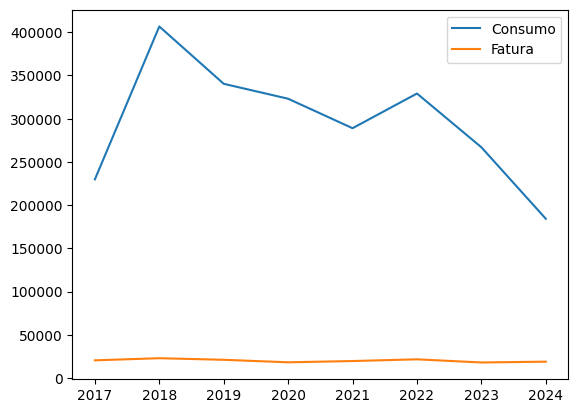

In [7]:
consumo_ano = df.groupby('ANO')['CONSUMO-KWH'].sum()
fatura_ano = df.groupby('ANO')['VALOR BRUTO DA FATURA'].mean()

plt.plot(consumo_ano.index, consumo_ano.values, label='Consumo')
plt.plot(fatura_ano.index, fatura_ano.values, label='Fatura')
plt.legend()
plt.show()

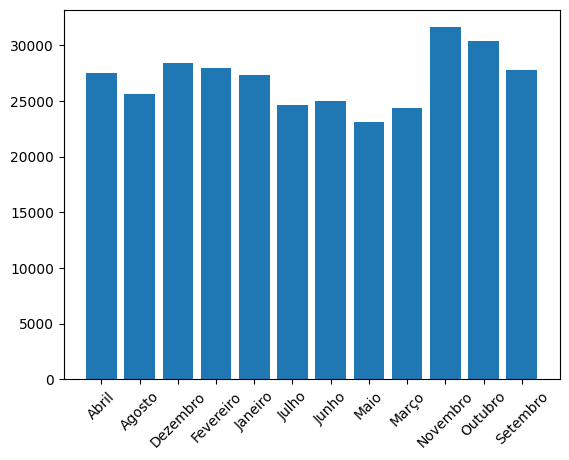

In [8]:
consumo_mes = df.groupby('MÊS')['CONSUMO-KWH'].mean()

plt.bar(consumo_mes.index, consumo_mes.values)
plt.xticks(rotation=45)
plt.show()

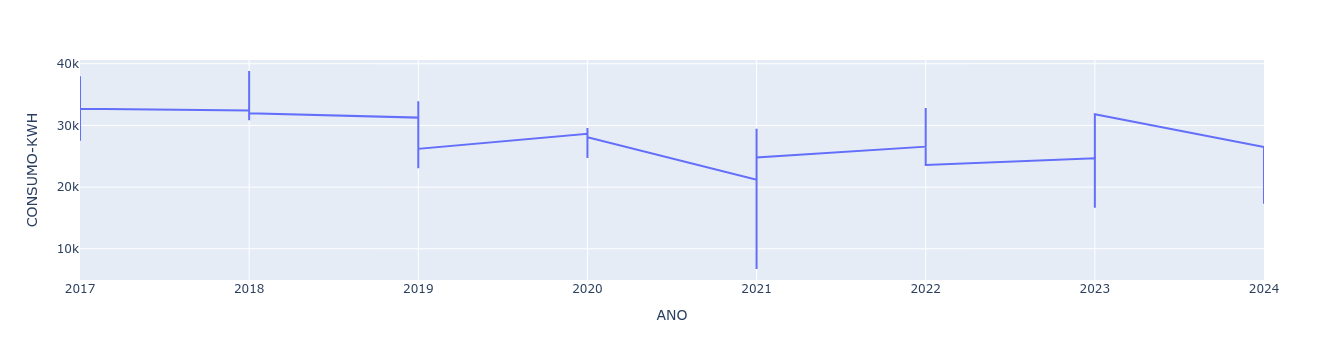

In [9]:
import plotly.express as px

fig = px.line(df, x='ANO', y='CONSUMO-KWH')
fig.show()

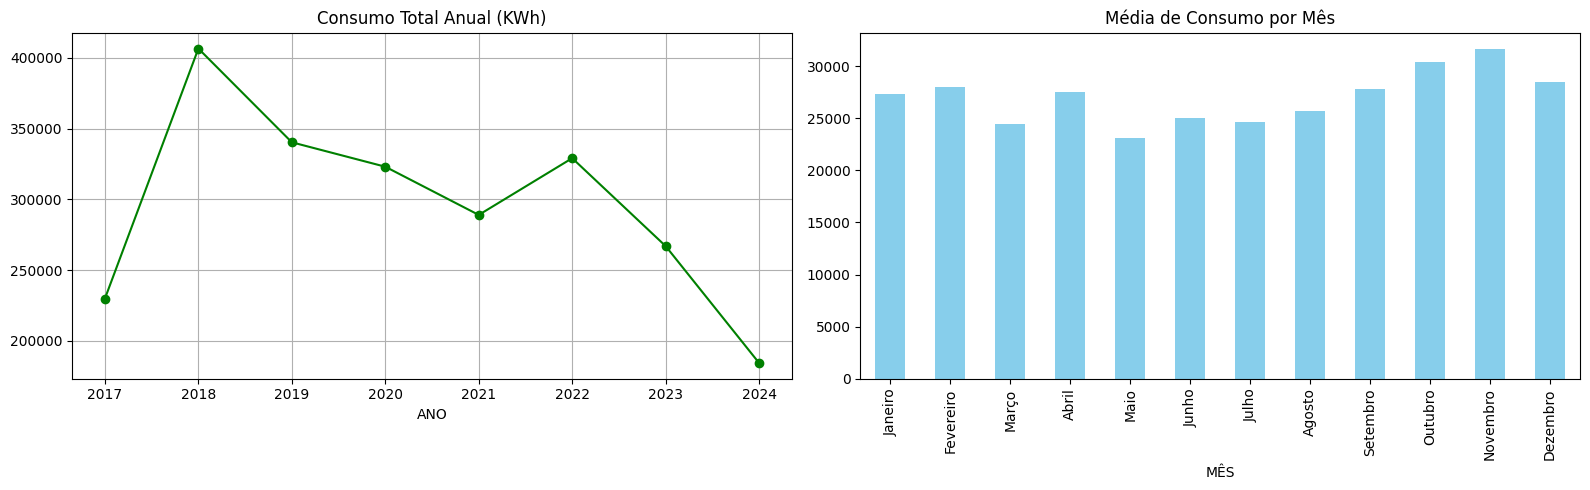

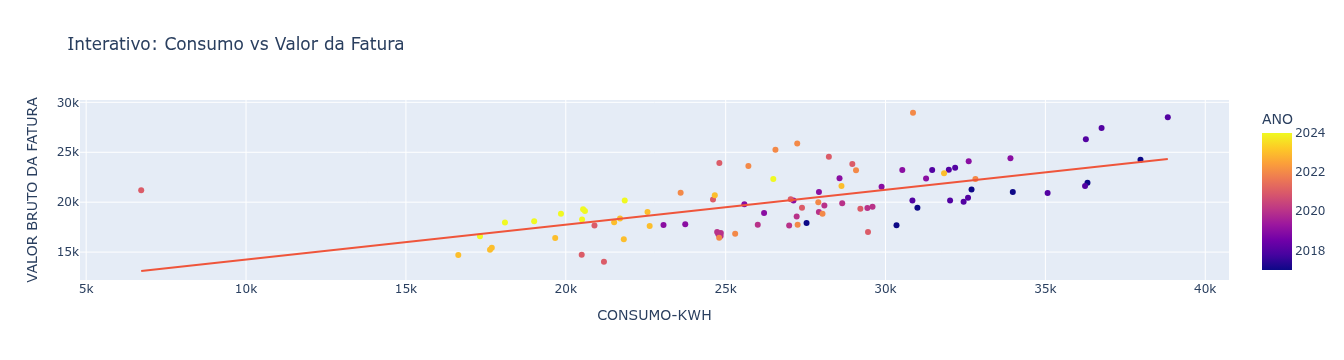

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# --- 1. CARREGAMENTO ---
url = 'https://raw.githubusercontent.com/AndersonSalata/Materiais_Alunos_EAD/main/consumo-de-energia-eletrica-no-palacio-do-jaburu-2017-2024-setembro.csv'
df = pd.read_csv(url, sep=';', encoding='latin1')

# --- 2. LIMPEZA ---
df.columns = df.columns.str.strip()
df['VALOR BRUTO DA FATURA'] = df['VALOR BRUTO DA FATURA'].astype(str).str.replace('R$', '', regex=False).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
df['VALOR BRUTO DA FATURA'] = pd.to_numeric(df['VALOR BRUTO DA FATURA'], errors='coerce')

# --- 3. CÁLCULOS E GRÁFICOS ESTÁTICOS ---
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico A: Consumo Total por Ano
df.groupby('ANO')['CONSUMO-KWH'].sum().plot(kind='line', marker='o', ax=ax[0], color='green')
ax[0].set_title('Consumo Total Anual (KWh)')
ax[0].grid(True)

# Gráfico B: Média Mensal (Sazonalidade)
meses = ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho', 'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro']
df.groupby('MÊS')['CONSUMO-KWH'].mean().reindex(meses).plot(kind='bar', ax=ax[1], color='skyblue')
ax[1].set_title('Média de Consumo por Mês')
plt.tight_layout()
plt.show()

# --- 4. GRÁFICO INTERATIVO (CORRELAÇÃO) ---
fig_interativo = px.scatter(df, x="CONSUMO-KWH", y="VALOR BRUTO DA FATURA", color="ANO", 
                 hover_data=['MÊS'], title="Interativo: Consumo vs Valor da Fatura", trendline="ols")
fig_interativo.show()